In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import os

In [12]:
testnum = "Test-3"
model_dir = f"{testnum}/models"
plot_dir = f"{testnum}/plots"

In [13]:
# Create directory to save results
os.makedirs(testnum, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)
os.makedirs(plot_dir, exist_ok=True)

In [14]:
# Load Fashion MNIST dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize and reshape the data
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encode the labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)


In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import regularizers, callbacks

# Image Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.10,
    width_shift_range=0.1,
    height_shift_range=0.1
)
datagen.fit(x_train)

In [16]:
# Build the improved CNN model
model = models.Sequential([
    layers.Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    layers.Flatten(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [17]:
# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
early_stop = callbacks.EarlyStopping(patience=6, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

In [18]:
# Fit using augmented data
history = model.fit(datagen.flow(x_train, y_train_cat, batch_size=64),
                    validation_data=(x_test, y_test_cat),
                    epochs=40,
                    callbacks=[early_stop, reduce_lr])

Epoch 1/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 137s 141ms/step - accuracy: 0.6629 - loss: 1.4425 - val_accuracy: 0.8294 - val_loss: 0.7218 - learning_rate: 0.0010
Epoch 2/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 133s 142ms/step - accuracy: 0.8043 - loss: 0.7588 - val_accuracy: 0.8512 - val_loss: 0.5705 - learning_rate: 0.0010
Epoch 3/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 132s 141ms/step - accuracy: 0.8309 - loss: 0.6258 - val_accuracy: 0.8626 - val_loss: 0.5176 - learning_rate: 0.0010
Epoch 4/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 131s 139ms/step - accuracy: 0.8453 - loss: 0.5773 - val_accuracy: 0.8753 - val_loss: 0.4869 - learning_rate: 0.0010
Epoch 5/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 133s 142ms/step - accuracy: 0.8532 - loss: 0.5577 - val_accuracy: 0.8839 - val_loss: 0.4824 - learning_rate: 0.0010
Epoch 6/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 130s 139ms/step - accuracy: 0.8581 - loss: 0.5465 - val_accuracy: 0.8609 - val_loss: 0.5411 - learning_rate: 0.0010
Epoch 7/40
938/938 ━━━━━━━━━━━━━━━━━━━━ 116s 124ms/step - accura

313/313 - 4s - 14ms/step - accuracy: 0.9256 - loss: 0.2445



🚀 Final Test Accuracy: 92.56%


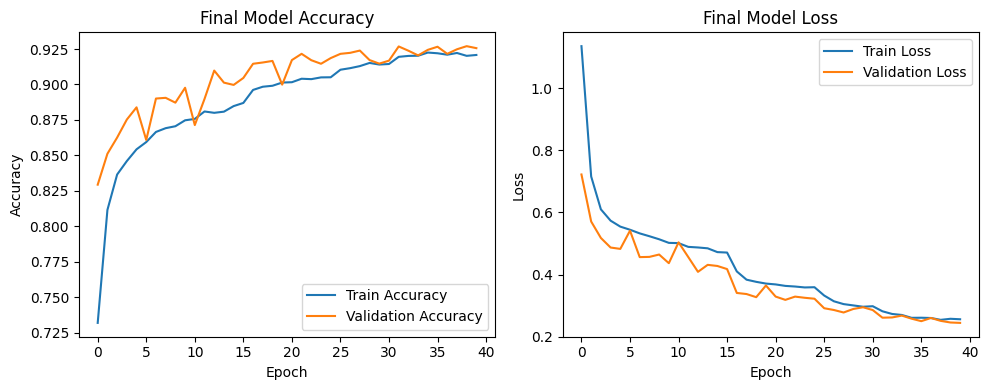

In [19]:
# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=2)
print(f"\n🚀 Final Test Accuracy: {test_acc * 100:.2f}%")

# Save model
model.save(f"{model_dir}/final_cnn_model.h5")

# Save plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Final Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Final Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig(f"{plot_dir}/final_cnn_training_plot.png")
plt.show()
